# 05 — Träna Epic-modellen
Tränar på `data/epic_dataset/` (manuellt kurerad epic/thin-data).

**Custom CNN — inte MobileNetV2.** Transfer learning testades men gav sämre resultat än denna arkitektur på den städade datan.

In [87]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

DATA_DIR   = 'data/epic_dataset'
IMG_SIZE   = (178, 178)
BATCH_SIZE = 32
SEED       = 42
MODEL_OUT  = 'models/epic_detector.keras'

print('TensorFlow:', tf.__version__)
print(f'Epic: {len(os.listdir(os.path.join(DATA_DIR, "epic")))}')
print(f'Thin: {len(os.listdir(os.path.join(DATA_DIR, "thin")))}')

TensorFlow: 2.16.2
Epic: 922
Thin: 1223


## Ladda dataset

In [83]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

print('Klasser:', train_ds.class_names)
print('=> epic=0, thin=1 => epic_score = 1 - model_output (innan omskalning)')

Found 2145 files belonging to 2 classes.
Using 1716 files for training.
Found 2145 files belonging to 2 classes.
Using 429 files for validation.
Klasser: ['epic', 'thin']
=> epic=0, thin=1 => epic_score = 1 - model_output (innan omskalning)


## Bygg modellen

In [84]:
def build_epic_model():
    data_augmentation = tf.keras.Sequential([
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomRotation(0.03),
        tf.keras.layers.RandomZoom(0.05),
        tf.keras.layers.RandomContrast(0.10),
    ])

    model = tf.keras.Sequential([
        data_augmentation,
        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(256, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.25),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model


epic_model = build_epic_model()

epic_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

print('Modell byggd!')

Modell byggd!


## Träna

In [85]:
history = epic_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=35,
    callbacks=[early_stop]
)

results = epic_model.evaluate(val_ds)
loss, acc = results[0], results[1]
print(f'\nAccuracy: {acc*100:.1f}%')

Epoch 1/35
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 411ms/step - accuracy: 0.6550 - loss: 0.6031 - precision: 0.6793 - recall: 0.7274 - val_accuracy: 0.7949 - val_loss: 0.4446 - val_precision: 0.7862 - val_recall: 0.9122
Epoch 2/35
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 421ms/step - accuracy: 0.8683 - loss: 0.3042 - precision: 0.8816 - recall: 0.8835 - val_accuracy: 0.9138 - val_loss: 0.2049 - val_precision: 0.9004 - val_recall: 0.9656
Epoch 3/35
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 436ms/step - accuracy: 0.9231 - loss: 0.1823 - precision: 0.9251 - recall: 0.9386 - val_accuracy: 0.9394 - val_loss: 0.1618 - val_precision: 0.9720 - val_recall: 0.9275
Epoch 4/35
54/54 ━━━━━━━━━━━━━━━━━━━━ 23s 426ms/step - accuracy: 0.9371 - loss: 0.1539 - precision: 0.9504 - recall: 0.9365 - val_accuracy: 0.9441 - val_loss: 0.1527 - val_precision: 0.9685 - val_recall: 0.9389
Epoch 5/35
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 416ms/step - accuracy: 0.9540 - loss: 0.1216 - precision: 0.9584 - recall: 0.9594 - val_accuracy: 0.9487 - val_los

## Utvärdering

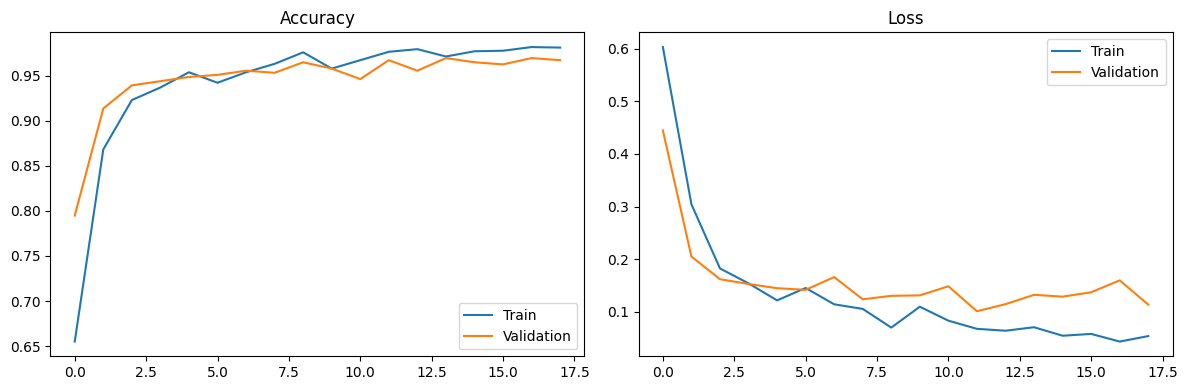

2026-06-22 02:09:01.401497: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


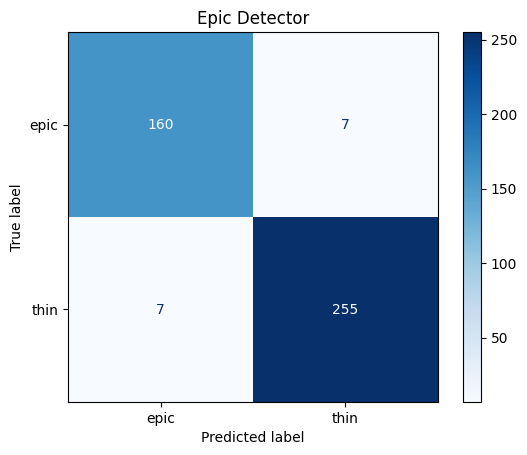

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].legend()
plt.tight_layout()
os.makedirs('presentation', exist_ok=True)
plt.savefig('presentation/training_curves_epic.png', dpi=150, bbox_inches='tight')
plt.show()

y_true, y_pred = [], []
for images, labels_batch in val_ds:
    preds = epic_model.predict(images, verbose=0).flatten()
    y_true.extend(labels_batch.numpy().astype(int))
    y_pred.extend((preds > 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=val_ds.class_names)
disp.plot(values_format='d', cmap='Blues')
plt.title('Epic Detector')
plt.savefig('presentation/confusion_epic.png', dpi=150, bbox_inches='tight')
plt.show()

## Spara

In [88]:
os.makedirs('models', exist_ok=True)
epic_model.save(MODEL_OUT)
print(f'Sparad: {MODEL_OUT}')

Sparad: models/epic_detector.keras


## Kalibrera epic_score
Modellen blir mycket säker (`thin_prob` nära 0 eller 1), så `1 - thin_prob` mättas direkt vid 0/100 för det mesta. Vi skalar om med en log-sigmoid: `score = 1 / (1 + exp(steepness * (log10(thin_prob) - log10(center))))`. Här bestämmer vi `center` och `steepness` empiriskt från den faktiska fördelningen, istället för att gissa.

In [63]:
import numpy as np

# Scora hela datasetet (train + val) med den färdiga modellen
full_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False
)
class_names = full_ds.class_names  # ['epic', 'thin']

all_thin_probs, all_labels = [], []
for images, labels_batch in full_ds:
    preds = epic_model.predict(images, verbose=0).flatten()
    all_thin_probs.extend(preds)
    all_labels.extend(labels_batch.numpy().flatten().astype(int))

all_thin_probs = np.array(all_thin_probs)
all_labels     = np.array(all_labels)

epic_probs = all_thin_probs[all_labels == 0]  # true epic
thin_probs = all_thin_probs[all_labels == 1]  # true thin

print(f'Klasser: {class_names}')
print(f'Epic — median thin_prob: {np.median(epic_probs):.6f}')
print(f'Thin — median thin_prob: {np.median(thin_probs):.6f}')

Found 2186 files belonging to 2 classes.
Klasser: ['epic', 'thin']
Epic — median thin_prob: 0.002222
Thin — median thin_prob: 0.999520


2026-06-21 23:30:42.427495: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


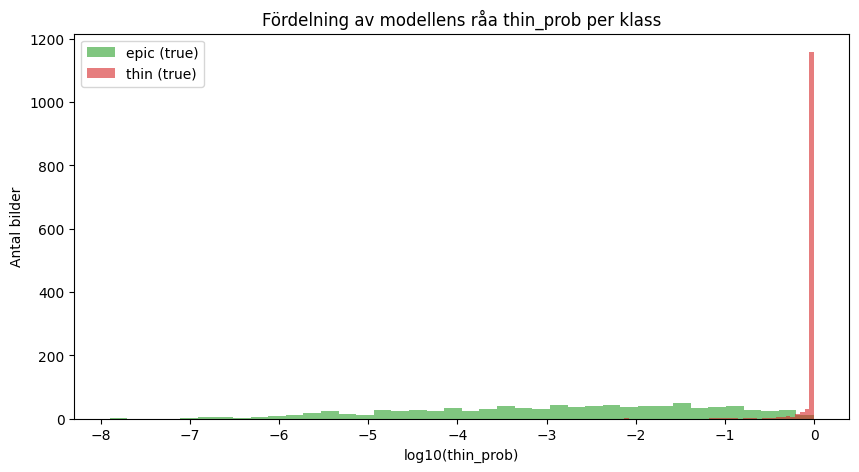

Föreslaget center (mitt mellan klassernas medianer): 0.047123


In [64]:
# Plotta fördelningen på log-skala — visar hur väl separerade klasserna är
plt.figure(figsize=(10, 5))
plt.hist(np.log10(np.clip(epic_probs, 1e-15, 1)), bins=40, alpha=0.6, label='epic (true)', color='tab:green')
plt.hist(np.log10(np.clip(thin_probs, 1e-15, 1)), bins=40, alpha=0.6, label='thin (true)', color='tab:red')
plt.xlabel('log10(thin_prob)')
plt.ylabel('Antal bilder')
plt.title('Fördelning av modellens råa thin_prob per klass')
plt.legend()
plt.show()

# Förslag på center: mittpunkten mellan klassernas medianer i log-skala
suggested_center = 10 ** ((np.log10(np.median(epic_probs) + 1e-15) + np.log10(np.median(thin_probs) + 1e-15)) / 2)
print(f'Föreslaget center (mitt mellan klassernas medianer): {suggested_center:.6f}')

In [67]:
def thin_prob_to_epic_score(thin_prob, center, steepness):
    thin_prob = max(float(thin_prob), 1e-15)
    x = np.log10(thin_prob)
    c = np.log10(center)
    score = 1 / (1 + np.exp(steepness * (x - c)))
    return float(np.clip(score, 0.0, 1.0))


# Testa olika steepness med det föreslagna center — vill se en fin spridning
# över epic_score, inte allt klumpat vid 0 eller 100
CENTER = 0.1  # justera manuellt om du vill efter att ha sett plotten ovan

for steepness in [0.6, 0.8, 1.0, 1.2, 1.4]:
    scores_epic = [thin_prob_to_epic_score(p, CENTER, steepness) for p in epic_probs]
    scores_thin = [thin_prob_to_epic_score(p, CENTER, steepness) for p in thin_probs]
    print(f'steepness={steepness}: epic median={np.median(scores_epic)*100:.1f}  thin median={np.median(scores_thin)*100:.1f}')

steepness=0.6: epic median=72.9  thin median=35.4
steepness=0.8: epic median=79.0  thin median=31.0
steepness=1.0: epic median=83.9  thin median=26.9
steepness=1.2: epic median=87.9  thin median=23.2
steepness=1.4: epic median=91.0  thin median=19.8


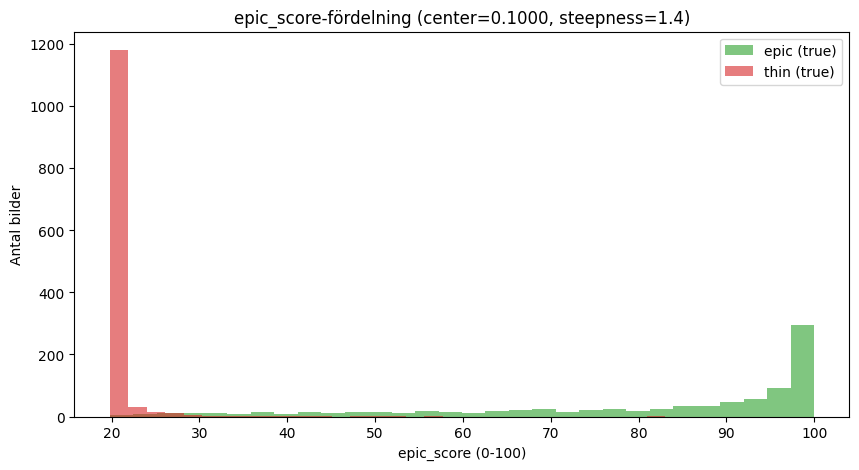


Slutgiltiga värden att använda i app.py:
center    = 0.1000
steepness = 1.4


In [68]:
# Histogram av epic_score för en specifik steepness — välj värdet som gav bäst spridning ovan
FINAL_STEEPNESS = 1.4  # byt baserat på vad som gav bra spridning i cellen ovan

scores_epic = [thin_prob_to_epic_score(p, CENTER, FINAL_STEEPNESS) for p in epic_probs]
scores_thin = [thin_prob_to_epic_score(p, CENTER, FINAL_STEEPNESS) for p in thin_probs]

plt.figure(figsize=(10, 5))
plt.hist(np.array(scores_epic) * 100, bins=30, alpha=0.6, label='epic (true)', color='tab:green')
plt.hist(np.array(scores_thin) * 100, bins=30, alpha=0.6, label='thin (true)', color='tab:red')
plt.xlabel('epic_score (0-100)')
plt.ylabel('Antal bilder')
plt.title(f'epic_score-fördelning (center={CENTER:.4f}, steepness={FINAL_STEEPNESS})')
plt.legend()
plt.show()

print(f'\nSlutgiltiga värden att använda i app.py:')
print(f'center    = {CENTER:.4f}')
print(f'steepness = {FINAL_STEEPNESS}')

In [8]:
from PIL import Image

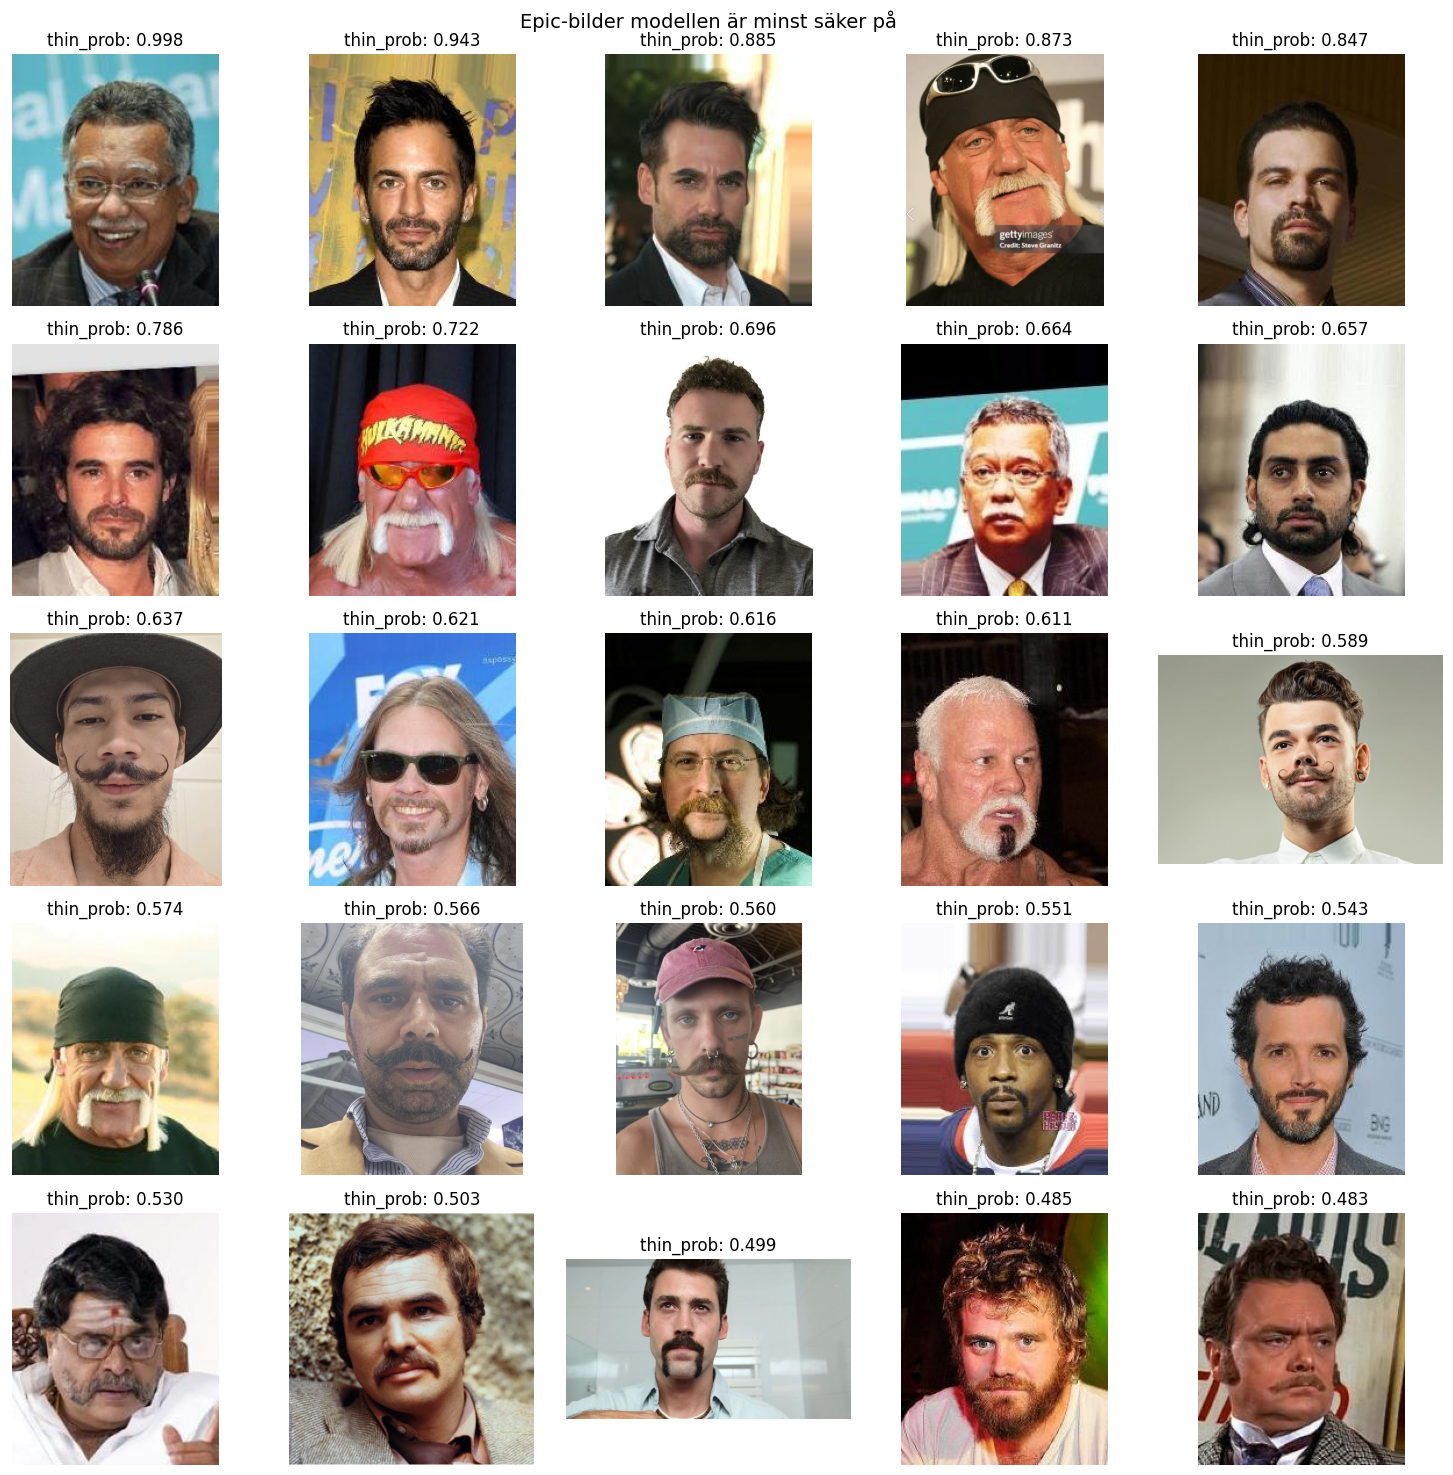

In [74]:
# Hitta vilka epic-bilder som fick lägst score
epic_filenames = [f for f in os.listdir(os.path.join(DATA_DIR, 'epic'))
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

# Matcha mot all_thin_probs (kräver att full_ds inte blandade ordningen — shuffle=False ovan)
epic_idx = np.where(all_labels == 0)[0]
epic_fnames_sorted_by_path = sorted(epic_filenames)  # image_dataset_from_directory sorterar alfabetiskt per klass

worst_epic = sorted(zip(epic_fnames_sorted_by_path, epic_probs), key=lambda x: x[1], reverse=True)[:25]

plt.figure(figsize=(15, 15))
for i, (fname, prob) in enumerate(worst_epic):
    img = Image.open(os.path.join(DATA_DIR, 'epic', fname))
    plt.subplot(5, 5, i + 1)
    plt.imshow(img)
    plt.title(f'thin_prob: {prob:.3f}')
    plt.axis('off')
plt.suptitle('Epic-bilder modellen är minst säker på', fontsize=14)
plt.tight_layout()
plt.show()